In [2]:
import os
import warnings
import requests
import librosa
import numpy as np
import pandas as pd
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import column, row, gridplot
from bokeh.models import Span, LinearColorMapper, ColorBar, FixedTicker

# Initialize Bokeh for notebook output
output_notebook()

def download_audio(audio_url: str, local_path: str):
    """Download audio file from a URL to a local path."""
    if not os.path.exists(local_path):
        print(f"Downloading audio from {audio_url}...")
        response = requests.get(audio_url)
        response.raise_for_status()  # Raise an error for bad status
        with open(local_path, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded audio to {local_path}.")
    else:
        print(f"Audio file {local_path} already exists. Skipping download.")

def load_cuepoints(url: str, name: str, color: str, column_name: str = 'TIME'):
    """Load cuepoints from a CSV file specifying the column name for onset times."""
    try:
        df = pd.read_csv(url, usecols=[column_name])
        peaks_in_sec = df[column_name].dropna().values
        return {'name': name, 'times': peaks_in_sec, 'color': color}
    except Exception as e:
        warnings.warn(f"Failed to load cuepoints from {url}: {e}")
        return None

def extract_features(y_segment: np.ndarray, sr: int, hop_length: int):
    """Extract various audio features from a segment."""
    features = {}
    features['amplitude_envelope'] = librosa.onset.onset_strength(y=y_segment, sr=sr, hop_length=hop_length)
    S = librosa.feature.melspectrogram(y=y_segment, sr=sr, hop_length=hop_length)
    features['melspectrogram'] = S
    features['spectral_flux'] = np.diff(S, axis=1)
    features['zero_crossing_rate'] = librosa.feature.zero_crossing_rate(y_segment, hop_length=hop_length)[0]
    features['spectral_centroid'] = librosa.feature.spectral_centroid(y=y_segment, sr=sr, hop_length=hop_length)[0]
    return features

def create_time_axis(num_frames: int, sr: int, hop_length: int, start_time: float):
    """Create a time axis for plotting."""
    return librosa.frames_to_time(np.arange(num_frames), sr=sr, hop_length=hop_length) + start_time

def plot_feature(feature_name: str, feature_data: np.ndarray, times: np.ndarray, title: str, y_label: str, width=400, height=300):
    """Create a Bokeh figure for a specific audio feature without legends."""
    p = figure(title=title, x_axis_label='Time (s)', y_axis_label=y_label, width=width, height=height)
    p.line(times, feature_data, line_width=2)
    return p

def plot_spectrogram(mel_db: np.ndarray, times: np.ndarray, sr: int, hop_length: int, start_time: float, title: str, y_label: str, width=400, height=300):
    """Create a Bokeh figure for the Mel-spectrogram."""
    p = figure(title=title, x_axis_label='Time (s)', y_axis_label=y_label, width=width, height=height)

    color_mapper = LinearColorMapper(palette="Viridis256", low=np.min(mel_db), high=np.max(mel_db))

    p.image(image=[mel_db],
            x=times[0],
            y=0,
            dw=times[-1] - times[0],
            dh=mel_db.shape[0],
            color_mapper=color_mapper)

    color_bar = ColorBar(color_mapper=color_mapper, label_standoff=12, location=(0, 0), title='dB')
    p.add_layout(color_bar, 'right')

    mel_frequencies = librosa.mel_frequencies(n_mels=mel_db.shape[0], fmin=0, fmax=sr/2)
    tick_positions = np.linspace(0, mel_db.shape[0]-1, num=10, dtype=int)
    tick_labels = [f"{freq:.1f}" for freq in mel_frequencies[tick_positions]]

    p.yaxis.ticker = FixedTicker(ticks=tick_positions.tolist())
    p.yaxis.major_label_overrides = {int(pos): label for pos, label in zip(tick_positions, tick_labels)}

    return p

def plot_stft_spectrogram(y_segment: np.ndarray, sr: int, n_fft: int, hop_length_stft: int, y_min: int, y_max: int, start_time: float, title: str, width=400, height=300, interp_factor=0):
    """Create a Bokeh figure for the STFT spectrogram."""
    stft = librosa.stft(y=y_segment, n_fft=n_fft, hop_length=hop_length_stft)
    stft_db_full = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

    freqs_full = np.linspace(0, sr / 2, num=stft_db_full.shape[0])
    freq_indices = np.where((freqs_full >= y_min) & (freqs_full <= y_max))[0]

    stft_db = stft_db_full[freq_indices, :]
    freqs = freqs_full[freq_indices]

    # Interpolation between linear and log frequencies
    linear_freqs = np.linspace(y_min, y_max, num=len(freq_indices))
    log_freqs = np.logspace(np.log10(max(y_min, 1)), np.log10(y_max), num=len(freq_indices))
    interp_freqs = (1 - interp_factor) * linear_freqs + interp_factor * log_freqs

    num_ticks = min(10, len(interp_freqs))
    tick_indices = np.linspace(0, len(interp_freqs) - 1, num=num_ticks).astype(int)
    tick_locations = interp_freqs[tick_indices]
    tick_labels = [f"{int(freq)} Hz" for freq in tick_locations]

    p = figure(title=title, x_axis_label='Time (s)', y_axis_label='Frequency (Hz)',
               width=width, height=height, y_range=(y_min, y_max))

    color_mapper = LinearColorMapper(palette="Viridis256", low=np.min(stft_db), high=np.max(stft_db))

    times_stft = librosa.frames_to_time(np.arange(stft_db.shape[1]), sr=sr, hop_length=hop_length_stft) + start_time

    p.image(image=[stft_db],
            x=times_stft[0],
            y=y_min,
            dw=times_stft[-1] - times_stft[0],
            dh=y_max - y_min,
            color_mapper=color_mapper)

    p.yaxis.ticker = FixedTicker(ticks=tick_locations.tolist())
    p.yaxis.major_label_overrides = {freq: label for freq, label in zip(tick_locations, tick_labels)}

    color_bar = ColorBar(
        color_mapper=color_mapper,
        label_standoff=12,
        location=(0, 0),
        title='dB'
    )
    p.add_layout(color_bar, 'right')

    return p

def add_custom_lines(plot, custom_intervals, duration):
    """Add custom interval lines to a plot."""
    for interval_set in custom_intervals:
        start = interval_set['start_time']
        step = interval_set['interval']
        color = interval_set.get('color', 'red')
        custom_time = start
        while custom_time < duration:
            span = Span(location=custom_time, dimension='height', line_color=color,
                        line_dash='dotted', line_width=2)
            plot.add_layout(span)
            custom_time += step

def add_cuepoints(plot, cuepoint_lists, start_time, end_time):
    """Add cuepoint lines to a plot."""
    for cuepoint in cuepoint_lists:
        cue_times = cuepoint['times']
        cue_color = cuepoint['color']
        relevant_times = cue_times[(cue_times >= start_time) & (cue_times <= end_time)]
        print(f"Adding {len(relevant_times)} cuepoints for '{cuepoint['name']}' in segment {start_time}-{end_time}s")
        for cue_time in relevant_times:
            span = Span(location=cue_time, dimension='height', line_color=cue_color,
                        line_dash='dashed', line_width=2)
            plot.add_layout(span)


# Parameters
audio_url = 'https://github.com/egorpol/beat_it/raw/refs/heads/main/examples/vision_spectral_mono.aif'
local_audio_path = 'examples/vision_spectral_mono.aif'

# # Download audio
# download_audio(audio_url, local_audio_path)

# Load audio
y, sr = librosa.load(local_audio_path)
duration = len(y) / sr
print(f"The audio file is {duration:.2f} seconds long.")

# STFT parameters
window_size = 1024
overlap = 0.5
hop_length_stft = int(window_size * (1 - overlap))
n_fft = window_size
y_min = 0
y_max = 10000

# Parameters for Grouped Analysis
initial_start_time = 0.103       # Starting time of the first interval in seconds
interval_duration = 0.4582       # Duration of each custom interval in seconds
intervals_per_group = 32         # Number of intervals per group (e.g., 16)
total_groups = 4                 # Number of groups to analyze (adjust as needed)

# Compute start_times and end_times based on the above parameters
start_times_grouped = []
end_times_grouped = []

for group in range(total_groups):
    start_time = initial_start_time + group * intervals_per_group * interval_duration
    end_time = start_time + intervals_per_group * interval_duration
    # Ensure end_time does not exceed audio duration
    if end_time > duration:
        end_time = duration
    start_times_grouped.append(start_time)
    end_times_grouped.append(end_time)

print("Grouped Segments (Start - End in seconds):")
for idx, (s, e) in enumerate(zip(start_times_grouped, end_times_grouped), 1):
    print(f"Group {idx}: {s:.3f} - {e:.3f} s")

# Selected Features to Plot
selected_features = ['stft_spectrogram']  # Modify as needed

# Lines to Plot
selected_lines = ['custom_interval_lines']  # Include 'custom_interval_lines' or 'cuepoints' if needed

# Define custom interval lines (if different from grouped intervals)
custom_intervals = [
    {'start_time': 0.103, 'interval': 0.4582, 'color': 'orange'},
    # Add more custom intervals here if needed
    # {'start_time': 0.6905, 'interval': 0.5563, 'color': 'orange'},
]

# Process each grouped segment
group_layouts = []  # List to hold layouts for each group

for idx, (start_time, end_time) in enumerate(zip(start_times_grouped, end_times_grouped), 1):
    print(f"\nProcessing Group {idx}: {start_time:.3f} - {end_time:.3f} seconds")

    # Extract segment
    start_sample = int(start_time * sr)
    end_sample = int(end_time * sr)
    y_segment = y[start_sample:end_sample]

    # Extract features
    hop_length = 512
    features = extract_features(y_segment, sr, hop_length)

    # Create time axes
    times_amplitude = create_time_axis(len(features['amplitude_envelope']), sr, hop_length, start_time)
    times_flux = create_time_axis(features['spectral_flux'].shape[1], sr, hop_length, start_time)
    times_zcr = create_time_axis(len(features['zero_crossing_rate']), sr, hop_length, start_time)
    times_centroid = create_time_axis(len(features['spectral_centroid']), sr, hop_length, start_time)
    times_mel = create_time_axis(features['melspectrogram'].shape[1], sr, hop_length, start_time)

    # Initialize plots dictionary
    plots = {}

    # Plot amplitude envelope
    if 'amplitude_envelope' in selected_features:
        p_amp = plot_feature('Amplitude Envelope', features['amplitude_envelope'],
                             times_amplitude, f"Amplitude Envelope (Group {idx})", 'Amplitude')
        plots['amplitude_envelope'] = p_amp

    # Plot spectral flux
    if 'spectral_flux' in selected_features:
        # Create a separate figure for Spectral Flux
        p_flux = figure(title=f"Spectral Flux (Group {idx})", x_axis_label='Time (s)',
                        y_axis_label='Spectral Flux', width=400, height=300)
        # Plot each Mel band's spectral flux as a separate line
        for band_idx, flux in enumerate(features['spectral_flux'], 1):
            p_flux.line(create_time_axis(len(flux), sr, hop_length, start_time), flux, line_width=1, color="blue")
        plots['spectral_flux'] = p_flux

    # Plot STFT spectrogram
    if 'stft_spectrogram' in selected_features:
        p_stft = plot_stft_spectrogram(y_segment, sr, n_fft, hop_length_stft, y_min, y_max,
                                       start_time, f"STFT Spectrogram (Group {idx})", width=1200, height=600)
        plots['stft_spectrogram'] = p_stft

    # Add custom interval lines
    if 'custom_interval_lines' in selected_lines:
        for plot in plots.values():
            add_custom_lines(plot, custom_intervals, duration)

    # Add cuepoints
    if 'cuepoints' in selected_lines and cuepoint_lists:
        for plot in plots.values():
            add_cuepoints(plot, cuepoint_lists, start_time, end_time)

    # Combine plots into a row
    group_row = row(*plots.values(), sizing_mode='stretch_width')
    group_layouts.append(group_row)

# Arrange all group layouts vertically
final_layout = column(*group_layouts, sizing_mode='stretch_both')

# Display the layout
show(final_layout)


Loading BokehJS ...

The audio file is 73.33 seconds long.
Grouped Segments (Start - End in seconds):
Group 1: 0.103 - 14.765 s
Group 2: 14.765 - 29.428 s
Group 3: 29.428 - 44.090 s
Group 4: 44.090 - 58.753 s

Processing Group 1: 0.103 - 14.765 seconds

Processing Group 2: 14.765 - 29.428 seconds

Processing Group 3: 29.428 - 44.090 seconds

Processing Group 4: 44.090 - 58.753 seconds


In [3]:
import numpy as np
from scipy.spatial.distance import cosine

# List to store flattened STFT spectrograms for each group
stft_vectors = []

for idx, (start_time, end_time) in enumerate(zip(start_times_grouped, end_times_grouped), 1):
    # Extract the audio segment
    start_sample = int(start_time * sr)
    end_sample = int(end_time * sr)
    y_segment = y[start_sample:end_sample]

    # Compute STFT
    stft = librosa.stft(y=y_segment, n_fft=n_fft, hop_length=hop_length_stft)
    stft_magnitude = np.abs(stft)

    # Flatten the magnitude spectrogram
    stft_vector = stft_magnitude.flatten()

    # Normalize the vector
    stft_vector /= np.linalg.norm(stft_vector)

    stft_vectors.append(stft_vector)

# Initialize similarity matrix
num_groups = len(stft_vectors)
similarity_matrix = np.zeros((num_groups, num_groups))

# Compute pairwise cosine similarity
for i in range(num_groups):
    for j in range(num_groups):
        similarity = 1 - cosine(stft_vectors[i], stft_vectors[j])
        similarity_matrix[i, j] = similarity

# Display the similarity matrix
print("Pairwise Cosine Similarities between Groups:")
print(similarity_matrix)


Pairwise Cosine Similarities between Groups:
[[1.         0.95164339 0.94994264 0.94551593]
 [0.95164339 1.         0.95585887 0.95153831]
 [0.94994264 0.95585887 1.         0.95594089]
 [0.94551593 0.95153831 0.95594089 1.        ]]


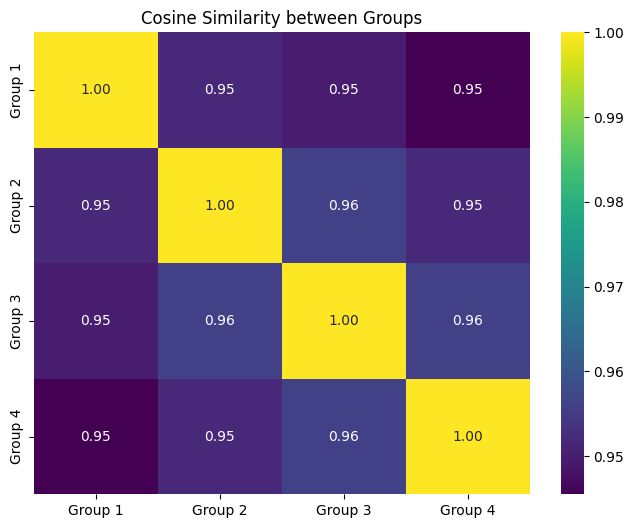

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap
group_labels = [f'Group {i+1}' for i in range(num_groups)]
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='viridis',
            xticklabels=group_labels, yticklabels=group_labels)
plt.title('Cosine Similarity between Groups')
plt.show()
